In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
import shutil
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API setup completed!")

Kaggle API setup completed!


In [ ]:
!kaggle datasets list -s plantvillage

ref                                                       title                                              size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
abdallahalidev/plantvillage-dataset                       PlantVillage Dataset                         4371949460  2019-09-01 11:52:26.883000         124694       1081  0.875            
emmarex/plantdisease                                      PlantVillage Dataset                          689512690  2018-10-30 01:16:23.440000         176905       1255  0.5625           
mohitsingh1804/plantvillage                               PlantVillage                                  857351099  2021-08-20 01:08:58.493000          19174        118  0.625            
soumiknafiul/plantvillage-dataset-labeled                 PlantVi

In [ ]:
!kaggle datasets download -d emmarex/plantdisease -p /content/dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 191MB/s]



In [ ]:
!pip install -q tensorflow scikit-learn matplotlib seaborn

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATA_DIR = Path("/content/dataset/PlantVillage")

In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for folder in sorted(DATA_DIR.iterdir()):
    if folder.is_dir():
        count = sum(
            1 for file in folder.rglob("*")
            if file.suffix.lower() in image_extensions
        )
        print(folder.name, ":", count, "images")

Pepper__bell___Bacterial_spot : 997 images
Pepper__bell___healthy : 1478 images
Potato___Early_blight : 1000 images
Potato___Late_blight : 1000 images
Potato___healthy : 152 images
Tomato_Bacterial_spot : 2127 images
Tomato_Early_blight : 1000 images
Tomato_Late_blight : 1909 images
Tomato_Leaf_Mold : 952 images
Tomato_Septoria_leaf_spot : 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite : 1676 images
Tomato__Target_Spot : 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus : 3208 images
Tomato__Tomato_mosaic_virus : 373 images
Tomato_healthy : 1591 images


In [ ]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Number of classes: 15
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:
os.makedirs("/content/agri_model", exist_ok=True)

with open("/content/agri_model/class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

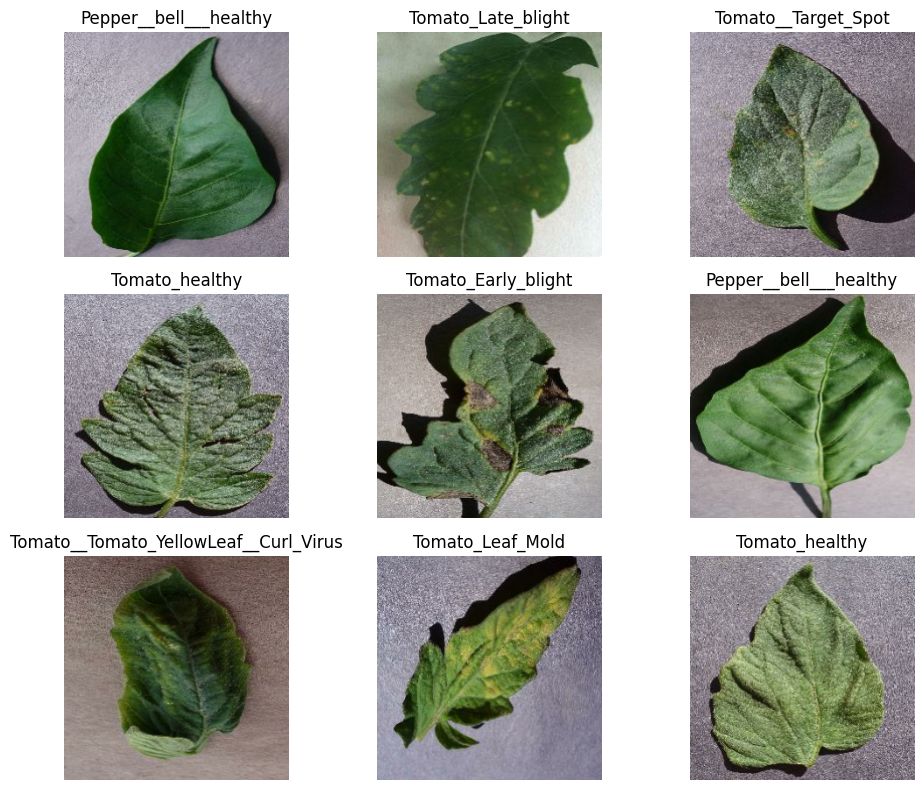

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# Data augmentation: used only during training.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
])

# Load pretrained EfficientNetB0.
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers.
base_model.trainable = False

# Build the complete model.
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

# EfficientNetB0 includes its own input rescaling.
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    ModelCheckpoint(
        "/content/agri_model/best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6550 - loss: 1.2115
Epoch 1: val_loss improved from None to 0.44574, saving model to /content/agri_model/best_model.keras

Epoch 1: finished saving model to /content/agri_model/best_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - accuracy: 0.7727 - loss: 0.8102 - val_accuracy: 0.8716 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 2/10
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8720 - loss: 0.4423
Epoch 2: val_loss improved from 0.44574 to 0.31895, saving model to /content/agri_model/best_model.keras

Epoch 2: finished saving model to /content/agri_model/best_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 76s 58ms/step - accuracy: 0.8779 - loss: 0.4147 - val_accuracy: 0.9043 - val_loss: 0.3189 - learning_rate: 0.0010
Epoch 3/10
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8971 - loss: 0.3424
Epoch 3: val_loss improved from 0.31895 to 0.28982, saving model to /content/agri_model/best

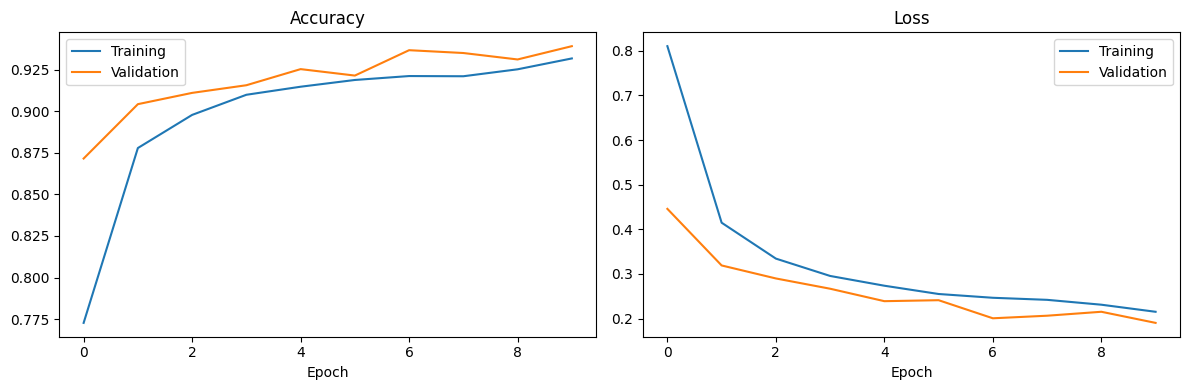

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Unfreeze the base model.
base_model.trainable = True

# Freeze all but the last 20 layers.
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep Batch Normalization layers frozen.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9317 - loss: 0.2058
Epoch 1: val_loss improved from 0.19025 to 0.14538, saving model to /content/agri_model/best_model.keras

Epoch 1: finished saving model to /content/agri_model/best_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 77s 64ms/step - accuracy: 0.9360 - loss: 0.1959 - val_accuracy: 0.9513 - val_loss: 0.1454 - learning_rate: 1.0000e-05
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9427 - loss: 0.1715
Epoch 2: val_loss improved from 0.14538 to 0.13786, saving model to /content/agri_model/best_model.keras

Epoch 2: finished saving model to /content/agri_model/best_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 64s 62ms/step - accuracy: 0.9431 - loss: 0.1714 - val_accuracy: 0.9532 - val_loss: 0.1379 - learning_rate: 1.0000e-05
Epoch 3/5
1031/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9457 - loss: 0.1588
Epoch 3: val_loss improved from 0.13786 to 0.13121, saving model to /content/agri_mo

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/agri_model/best_model.keras"
)

val_loss, val_accuracy = best_model.evaluate(val_ds)

print("Validation accuracy:", val_accuracy)

258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9627 - loss: 0.1202
Validation accuracy: 0.9626847505569458


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print("Accuracy:", accuracy_score(y_true, y_pred))

print(
    "Macro-F1:",
    f1_score(
        y_true,
        y_pred,
        average="macro"
    )
)

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        zero_division=0
    )
)

Accuracy: 0.9626847589047735
Macro-F1: 0.9588633813393556
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      1.00      0.99       200
                     Pepper__bell___healthy       0.99      0.99      0.99       302
                      Potato___Early_blight       0.98      1.00      0.99       189
                       Potato___Late_blight       0.98      0.97      0.98       188
                           Potato___healthy       0.91      0.97      0.94        31
                      Tomato_Bacterial_spot       0.99      0.96      0.98       441
                        Tomato_Early_blight       0.99      0.80      0.88       191
                         Tomato_Late_blight       0.95      0.97      0.96       341
                           Tomato_Leaf_Mold       1.00      0.91      0.95       185
                  Tomato_Septoria_leaf_spot       0.95      0.95      0.95       392
Tomato

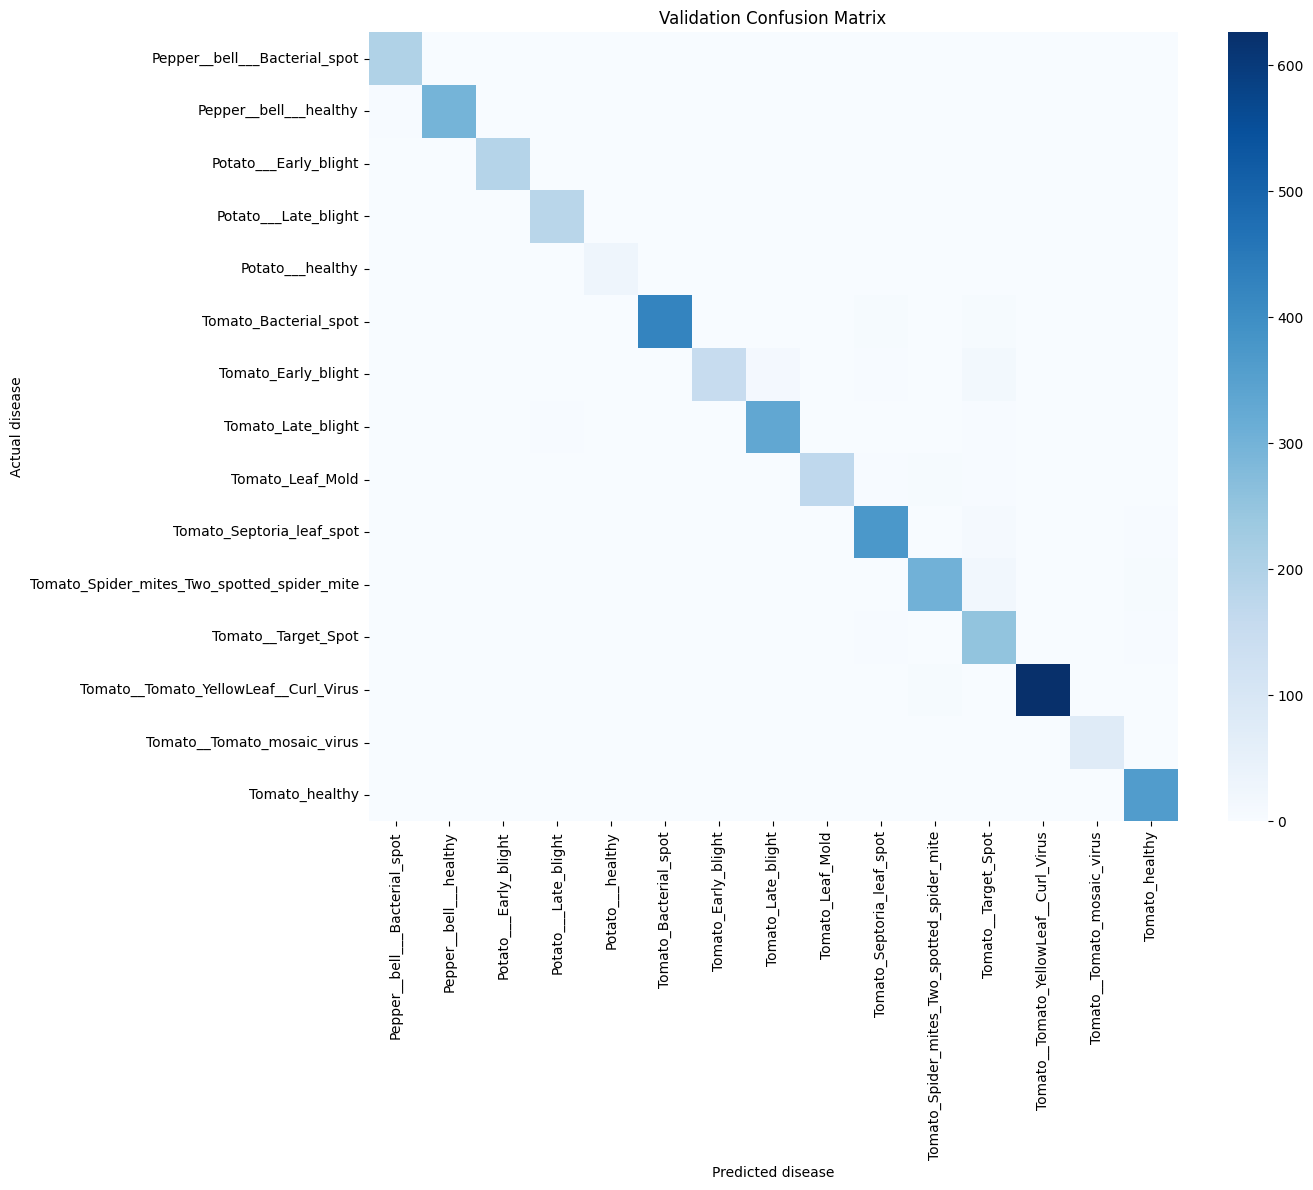

In [ ]:

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted disease")
plt.ylabel("Actual disease")
plt.title("Validation Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:

from PIL import Image

def predict(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    image_array = np.array(image, dtype=np.float32)
    image_array = np.expand_dims(image_array, axis=0)

    probabilities = best_model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = int(np.argmax(probabilities))

    return {
        "class_label": class_names[predicted_index],
        "confidence": float(probabilities[predicted_index])
    }

In [ ]:

from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

result = predict(image_path)

print("Predicted disease:", result["class_label"])
print("Confidence:", round(result["confidence"] * 100, 2), "%")

Saving 006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG to 006adb74-934f-448f-a14f-62181742127b___JR_B.Spot 3395.JPG
Predicted disease: Pepper__bell___Bacterial_spot
Confidence: 99.96 %


In [ ]:

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

MODEL_PATH = "/content/agri_model/best_model.keras"

CLASS_NAMES_PATH = "/content/agri_model/class_names.json"

# CHANGE THIS to your separate test dataset folder
TEST_DIR = "/content/drive/MyDrive/test_dataset"

# Final evaluation output folder
OUTPUT_DIR = "/content/agri_model/final_evaluation"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Model exists:", os.path.exists(MODEL_PATH))
print("Class names exist:", os.path.exists(CLASS_NAMES_PATH))
print("Test dataset exists:", os.path.isdir(TEST_DIR))

Model exists: True
Class names exist: True
Test dataset exists: False


In [ ]:

import tensorflow as tf
import json
import numpy as np

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

with open(CLASS_NAMES_PATH, "r") as f:
    class_names = json.load(f)

# Support both a list and a dictionary of class names
if isinstance(class_names, dict):
    class_names = list(class_names.values())

print("Model loaded successfully!")
print("Number of classes:", len(class_names))
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)
print("Class names:", class_names)

Model loaded successfully!
Number of classes: 15
Model input shape: (None, 224, 224, 3)
Model output shape: (None, 15)
Class names: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [ ]:

# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR,
#     image_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     label_mode="int",
#     shuffle=False
# )

# test_class_names = test_ds.class_names

# print("Test images loaded:", len(test_ds.file_paths))
# print("Test classes:", test_class_names)

# assert test_class_names == class_names, (
#     "Class order does not match your saved class_names.json!"
# )
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = np.concatenate([
    labels.numpy()
    for images, labels in val_ds
])

y_pred_probs = model.predict(val_ds, verbose=1)

y_pred = np.argmax(y_pred_probs, axis=1)

print("Validation Accuracy:",
      accuracy_score(y_true, y_pred) * 100)

print("Validation Precision:",
      precision_score(y_true, y_pred, average="macro") * 100)

print("Validation Recall:",
      recall_score(y_true, y_pred, average="macro") * 100)

print("Validation Macro-F1:",
      f1_score(y_true, y_pred, average="macro") * 100)

258/258 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step
Validation Accuracy: 8.81996607705355
Validation Precision: 6.709513995566637
Validation Recall: 6.707289306192071
Validation Macro-F1: 6.698492216531693
